In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, precision_recall_curve

In [3]:
df = pd.read_csv('../data/creditcard.csv')

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

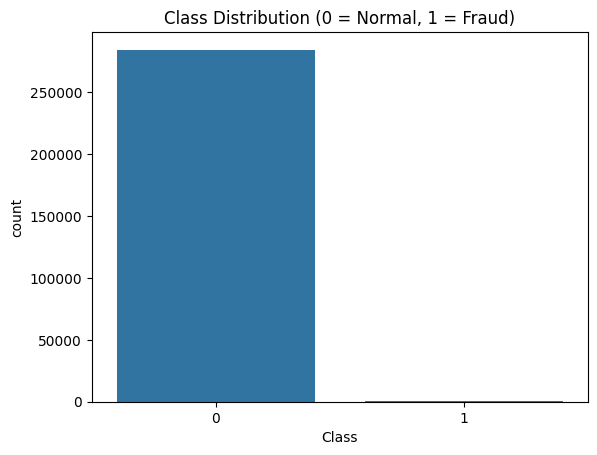

In [6]:
sns.countplot(x='Class', data=df)
plt.title("Class Distribution (0 = Normal, 1 = Fraud)")
plt.show()

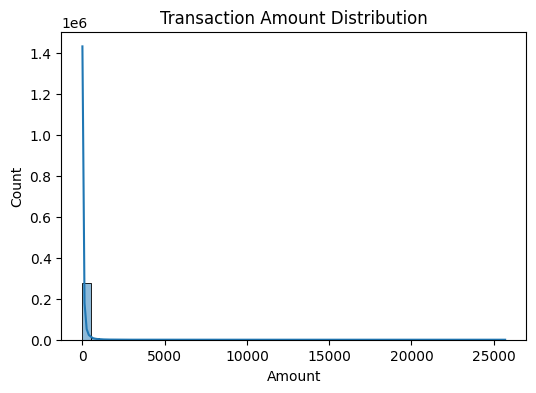

In [7]:
plt.figure(figsize=(6,4))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

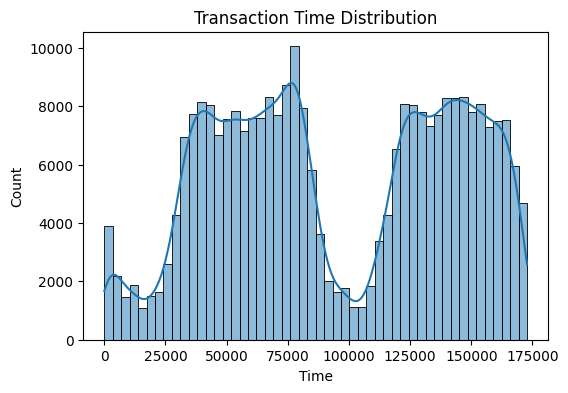

In [8]:
plt.figure(figsize=(6,4))
sns.histplot(df['Time'], bins=50, kde=True)
plt.title("Transaction Time Distribution")
plt.show()

In [9]:
scaler = RobustScaler()

df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1,1))

In [10]:
df.drop(['Amount','Time'], axis=1, inplace=True)

In [11]:
scaled_amount = df.pop('scaled_amount')
scaled_time = df.pop('scaled_time')

df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

In [12]:
df.head()

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.783274,-0.994983,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.269825,-0.994983,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.983721,-0.994972,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.418291,-0.994972,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,0.670579,-0.994960,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


In [13]:
normal_df = df[df['Class'] == 0]
fraud_df = df[df['Class'] == 1]

print("Normal:", normal_df.shape)
print("Fraud:", fraud_df.shape)

Normal: (284315, 31)
Fraud: (492, 31)


In [14]:
X = normal_df.drop('Class', axis=1)

In [15]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.001,   # approx fraud ratio
    random_state=42
)

iso_model.fit(X)

,n_estimators,100
,max_samples,'auto'
,contamination,0.001
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [16]:
X_full = df.drop('Class', axis=1)

df['iso_pred'] = iso_model.predict(X_full)

In [17]:
df['iso_pred'] = df['iso_pred'].map({1:0, -1:1})

In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_true = df['Class']
y_pred = df['iso_pred']

print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))

Precision: 0.27848101265822783
Recall: 0.22357723577235772
F1 Score: 0.2480270574971815


In [19]:
from sklearn.neighbors import LocalOutlierFactor

lof_model = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.001
)

In [20]:
df['lof_pred'] = lof_model.fit_predict(df.drop('Class', axis=1))

In [21]:
df['lof_pred'] = df['lof_pred'].map({1:0, -1:1})

In [22]:
y_pred_lof = df['lof_pred']

print("LOF Precision:", precision_score(y_true, y_pred_lof))
print("LOF Recall:", recall_score(y_true, y_pred_lof))
print("LOF F1 Score:", f1_score(y_true, y_pred_lof))

LOF Precision: 0.0
LOF Recall: 0.0
LOF F1 Score: 0.0


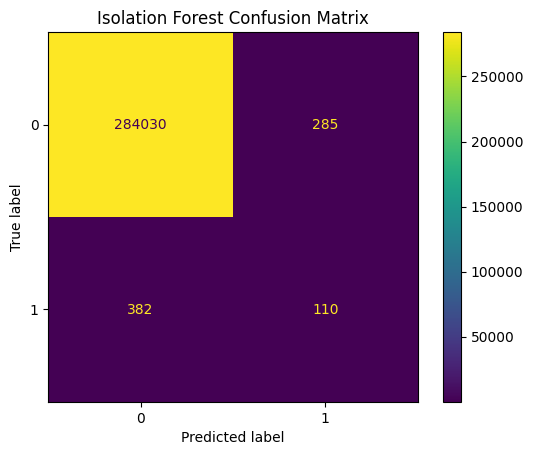

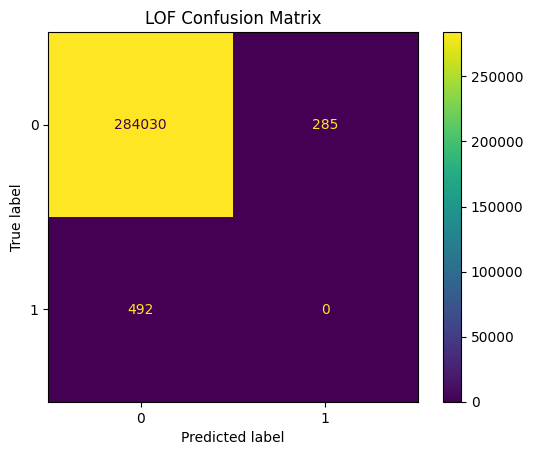

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
plt.title("Isolation Forest Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_true, y_pred_lof)
plt.title("LOF Confusion Matrix")
plt.show()

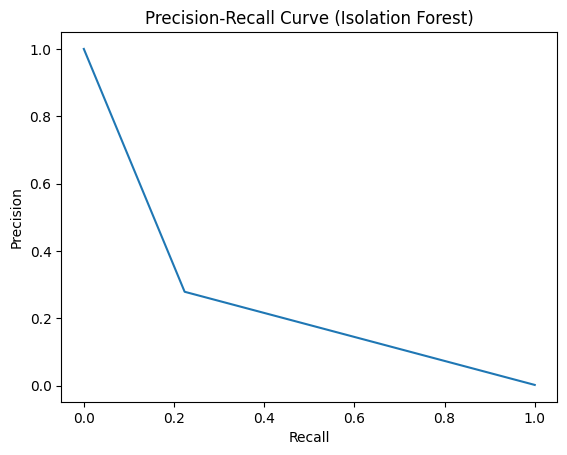

In [24]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_true, y_pred)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve (Isolation Forest)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

In [25]:
print("Isolation Forest -> Precision:", precision_score(y_true, y_pred))
print("Isolation Forest -> Recall:", recall_score(y_true, y_pred))
print("Isolation Forest -> F1:", f1_score(y_true, y_pred))

print("\nLOF -> Precision:", precision_score(y_true, y_pred_lof))
print("LOF -> Recall:", recall_score(y_true, y_pred_lof))
print("LOF -> F1:", f1_score(y_true, y_pred_lof))

Isolation Forest -> Precision: 0.27848101265822783
Isolation Forest -> Recall: 0.22357723577235772
Isolation Forest -> F1: 0.2480270574971815

LOF -> Precision: 0.0
LOF -> Recall: 0.0
LOF -> F1: 0.0


In [26]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df.drop(['Class','iso_pred','lof_pred'], axis=1))

df['pca1'] = pca_result[:,0]
df['pca2'] = pca_result[:,1]

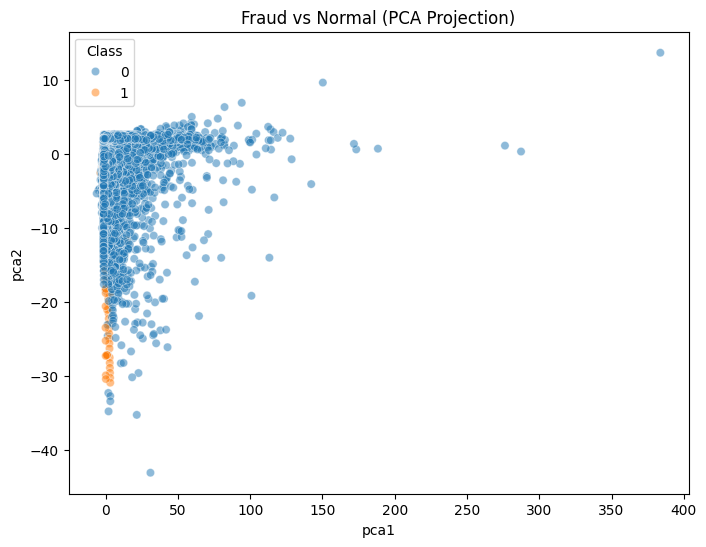

In [27]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='pca1', y='pca2', hue='Class', data=df, alpha=0.5)
plt.title("Fraud vs Normal (PCA Projection)")
plt.show()

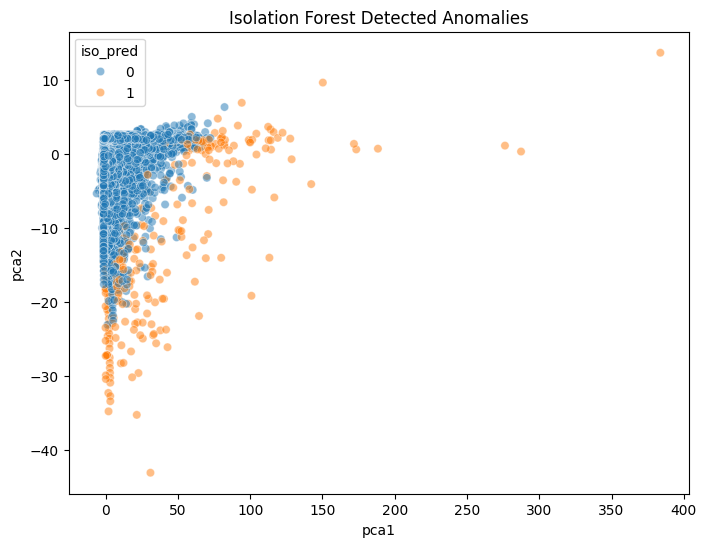

In [28]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='pca1', y='pca2', hue='iso_pred', data=df, alpha=0.5)
plt.title("Isolation Forest Detected Anomalies")
plt.show()

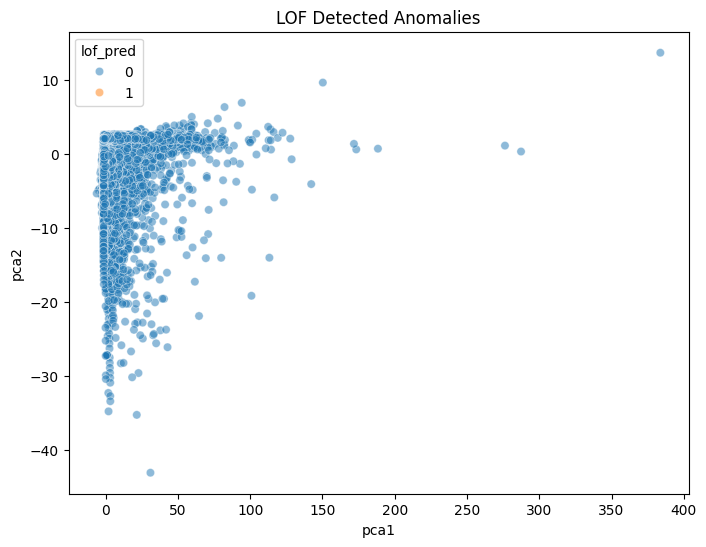

In [29]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='pca1', y='pca2', hue='lof_pred', data=df, alpha=0.5)
plt.title("LOF Detected Anomalies")
plt.show()